In [1]:
import pandas as pd
import numpy as np
from lxml import etree

In [2]:
src_file = 'source.v1.tei.xml'
ns = {"tei": "http://www.tei-c.org/ns/1.0", 
      "xml": "http://www.w3.org/TR/html4"}
p_xpath = "//tei:body//tei:p"

In [3]:
tree = etree.parse(src_file)  # Replace with your actual file path
root = tree.getroot()
p_elements = root.xpath(p_xpath, namespaces=ns)

In [4]:
def extract_text_excluding_notes(elem):
    
    # Grab paragraph ID
    p_id_list = elem.xpath('./@xml:id', namespaces=ns)
    if len(p_id_list) == 0:
        p_id = None
    else:
        p_id = int(p_id_list[0].replace('p', ''))
    
    # Serialize the <p> element to string    
    p_str = etree.tostring(elem, encoding="unicode")
    
    # Wrap it in a dummy root element
    wrapped = f"<wrapper xmlns='http://www.tei-c.org/ns/1.0'>{p_str}</wrapper>"
    wrapper_elem = etree.fromstring(wrapped)

    # Remove all <note> elements
    for note in wrapper_elem.xpath(".//tei:note", namespaces=ns):
        note.getparent().remove(note)

    # Get all remaining <p> elements and concatenate their text
    text_parts = []
    for p in wrapper_elem.xpath(".//tei:p", namespaces=ns):
        text_parts.append(''.join(p.itertext()))
    p_text = ' '.join(text_parts)

    # Return id and text
    return (p_id, p_text)

paragraphs = [extract_text_excluding_notes(p) for p in p_elements]

In [5]:
# Convert to dataframe
PARA = pd.DataFrame(paragraphs, columns=['para_id', 'para_str'])
PARA.para_id = PARA.para_id.ffill()
PARA.loc[PARA.para_id.isna(), 'para_id'] = 0
PARA.para_id = PARA.para_id.astype(int)
PARA['line_id'] = PARA.groupby('para_id').cumcount() + 1
PARA = PARA.set_index(['para_id','line_id'])

In [6]:
PARA

para_str
para_id line_id                           
0       1                        POPOL WUJ
        2                    OJER TAQ TZIJ
        3        XB'AN PA TINAMIT K'ICHE',
        4             RAMAQ' K'ICHE' WINAQ
        5               \n        \n      
...                                    ...
107     135                               
        136                               
        137                               
        138                               
        139                               

[4525 rows x 1 columns]

In [7]:
# Convert paragraphs to tokens
TOKEN = PARA.para_str.str.split(expand=True).stack().to_frame('token_str')
TOKEN.index.names = PARA.index.names + ['token_num']

In [ ]:
# Create normalized terms from tokens
TOKEN['term_str'] = (
    TOKEN
        .token_str.str.replace(r"\d+", "", regex=True)
        .str.replace('.', '')
        .str.replace(',', '')
        .str.lower()
        .str.strip()
)

# Remove blanks
TOKEN = TOKEN[~TOKEN.term_str.str.match(r'^\s*$')]

In [28]:
# Create a document-term matrix to extract statistics
DTM = TOKEN.groupby(['para_id', 'term_str']).term_str.count().unstack(fill_value=0)

In [29]:
DTM

term_str,a,a',a'on,ab'aj,ab'anel,ab'anoj,ab'i',ab'ix,ab'ixik,ab'ixom,...,yak,yakal,yakalik,yaki,yaklin,yamanik,yan,yitz',yojol,yub'jan
para_id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
104,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
105,0,0,0,2,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
VOCAB = DTM.sum().to_frame('n')
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()

In [31]:
VOCAB

,n,p
term_str,,
a,26,0.001441
a',4,0.000222
a'on,1,0.000055
ab'aj,16,0.000887
ab'anel,1,0.000055
...,...,...
yamanik,2,0.000111
yan,3,0.000166
yitz',1,0.000055


In [32]:
# Compute DFIDF to select significant terms
VOCAB['df'] = DTM.astype(bool).sum()
VOCAB['dfidf'] = VOCAB.df * np.log2(len(DTM)/VOCAB.df)

In [33]:
VOCAB.dfidf.describe()

count    3333.000000
mean       11.026864
std         9.199183
min         6.754888
25%         6.754888
50%         6.754888
75%        11.509775
max        57.318376
Name: dfidf, dtype: float64

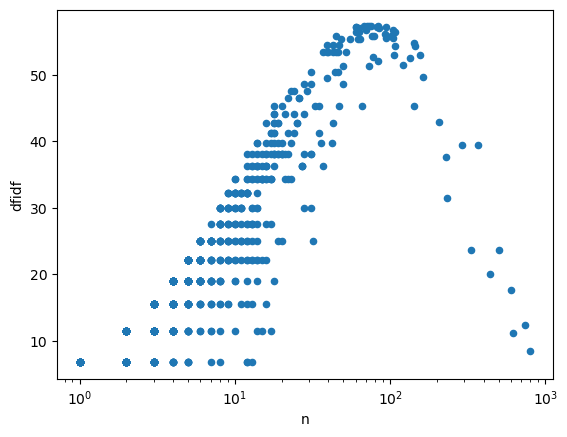

In [34]:
VOCAB.plot.scatter('n', 'dfidf', logx=True);

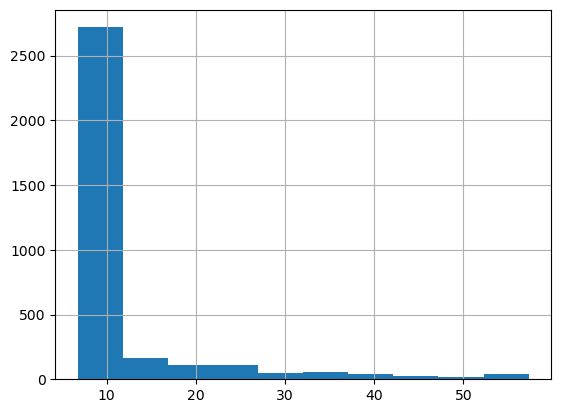

In [35]:
VOCAB.dfidf.hist();

In [36]:
VOCAB['dfidf_group'] = VOCAB.dfidf.round().astype(int)

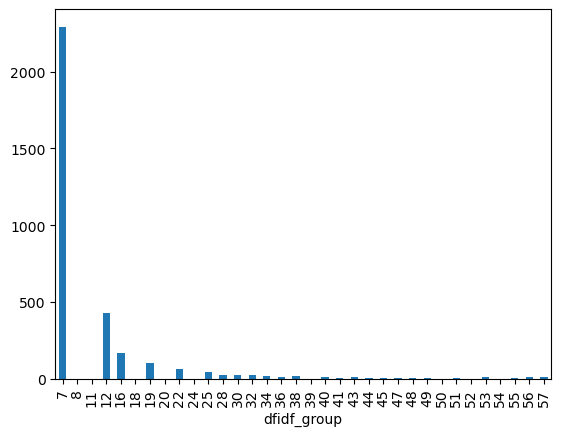

In [27]:
VOCAB.groupby('dfidf_group').count().n.sort_index().plot.bar();

In [37]:
VOCAB[VOCAB.dfidf_group >= 8]

,n,p,df,dfidf,dfidf_group
term_str,,,,,
a,26,0.001441,18,46.529325,47
a',4,0.000222,4,19.019550,19
ab'aj,16,0.000887,13,39.707821,40
ab'ix,5,0.000277,3,15.509775,16
ab'ixik,4,0.000222,4,19.019550,19
...,...,...,...,...,...
yakal,3,0.000166,3,15.509775,16
yakalik,3,0.000166,3,15.509775,16
yaki,2,0.000111,2,11.509775,12


In [38]:
VOCAB[VOCAB.dfidf_group < 8]

,n,p,df,dfidf,dfidf_group
term_str,,,,,
a'on,1,0.000055,1,6.754888,7
ab'anel,1,0.000055,1,6.754888,7
ab'anoj,1,0.000055,1,6.754888,7
ab'i',2,0.000111,1,6.754888,7
ab'ixom,1,0.000055,1,6.754888,7
...,...,...,...,...,...
ya'xel,1,0.000055,1,6.754888,7
yaklin,2,0.000111,1,6.754888,7
yitz',1,0.000055,1,6.754888,7


In [ ]:
# Chunk
n_chunks = 25

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message=".*swapaxes.*")
TOKEN['chunk_id'] = np.concatenate([
    np.full(len(chunk), i) 
    for i, chunk 
    in enumerate(np.array_split(TOKEN, n_chunks))
])
CHUNK = TOKEN.groupby('chunk_id').term_str.apply(lambda x: ' '.join(x)).to_frame('chunk_str')
CHUNK['n_tokens'] = CHUNK.chunk_str.str.split().str.len()

In [69]:
CHUNK

,chunk_str,n_tokens
chunk_id,,
0,popol wuj ojer taq tzij xb'an pa tinamit k'ich...,722
1,b'itol alom k'ajolom kixch'awoq kixsik'inoq mi...,722
2,e nab'e tzatz chi winaq xe'uxik waral chuwach ...,722
3,chi q'aq' jun ajpu pekul ya' xkanul makamob' j...,722
4,ri jun ajpu xb'alanq'e ta xkam k'ut ri wuqub' ...,722
5,lo are chi k'ut chiqab'ij uch'akatajik chik si...,722
6,ri jun ajpu xb'alanq'e chi re kab'raqan ma qit...,722
7,ch'amiyab'aq ch'amiyajolom kib'i' are chi k'u ...,722
8,ib'ate ipachq'ab' xe'uchax k'ut kixku'loq chuw...,722


In [68]:
TOKEN.to_csv("ajtzibab-TOKEN.csv", index=True)
VOCAB.to_csv("ajtzibab-VOCAB.csv", index=True)
CHUNK.to_csv("ajtzibab-CHUNK.csv", index=True)